# Assignment 2 — Data Wrangling (Academic performance)

This notebook creates a small `Students Performance` dataset (10 records) and demonstrates:

- Missing value detection and handling
- Outlier detection (IQR) and simple treatment (capping)
- A data transformation (Min–Max scaling) with before/after visuals and rationale

In [21]:
import pandas as pd
import numpy as np
# Create the dataset
data = {
    "Math_Score": [75,70,72,68,75,80,60,78,66,None],
    "Reading_Score": [78,82,None,75,90,95,77,92,None,89],
    "Writing_Score": [62,68,70,None,74,80,60,76,69,72],
    "Placement_Score": [80,85,90,85,95,100,76,96,88,93],
    "Club_Join_Date": [2018,2019,None,2018,2020,2021,2018,2021,2020,2021],
    "Placement_Offer_Count": [1,2,2,3,3,4,0,3,2,3]
}
df = pd.DataFrame(data)
# Save to CSV
file_path = "Students_Performance.csv"
df.to_csv(file_path, index=False)
file_path

'Students_Performance.csv'

In [22]:
df = pd.read_csv("Students_Performance.csv")
df.head()

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,75.0,78.0,62.0,80,2018.0,1
1,70.0,82.0,68.0,85,2019.0,2
2,72.0,NaN,70.0,90,NaN,2
3,68.0,75.0,NaN,85,2018.0,3
4,75.0,90.0,74.0,95,2020.0,3


## 1) Missing values — detection and handling

We detect missing values and apply sensible imputations: use mean for `Math_Score` (numeric, symmetric), median for `Reading_Score` and `Writing_Score` (robust to skew/outliers), and the minimum year for `Club_Join_Date` to indicate earliest join.

In [23]:
# Show missing counts
df.isna().sum()

Math_Score               1
Reading_Score            2
Writing_Score            1
Placement_Score          0
Club_Join_Date           1
Placement_Offer_Count    0
dtype: int64

In [ ]:
# Impute missing values (fixed and consistent)
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean())
df['Reading_Score'] = df['Reading_Score'].fillna(df['Reading_Score'].median())
df['Writing_Score'] = df['Writing_Score'].fillna(df['Writing_Score'].median())
df['Club_Join_Date'] = df['Club_Join_Date'].fillna(int(df['Club_Join_Date'].min()))
# Verify no missing values remain
df.isna().sum()

Math_Score               0
Reading_Score            0
Writing_Score            0
Placement_Score          0
Club_Join_Date           0
Placement_Offer_Count    0
dtype: int64

In [25]:
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,75.000000,78.0,62.0,80,2018.0,1
1,70.000000,82.0,68.0,85,2019.0,2
2,72.000000,85.5,70.0,90,2018.0,2
3,68.000000,75.0,70.0,85,2018.0,3
4,75.000000,90.0,74.0,95,2020.0,3
5,80.000000,95.0,80.0,100,2021.0,4
6,60.000000,77.0,60.0,76,2018.0,0
7,78.000000,92.0,76.0,96,2021.0,3
8,66.000000,85.5,69.0,88,2020.0,2
9,71.555556,89.0,72.0,93,2021.0,3


## 2) Outlier detection and treatment (IQR/capping)

We detect outliers using the IQR rule per numeric column, list flagged rows, and then apply quantile-based capping (flooring/capping) to reduce extreme effects while keeping all records.

In [26]:
import matplotlib.pyplot as plt
numeric_cols = ['Math_Score','Reading_Score','Writing_Score','Placement_Score','Placement_Offer_Count']
# Compute IQR and identify outliers
outlier_info = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_info[col] = { 'Q1':Q1, 'Q3':Q3, 'IQR':IQR, 'lower':lower, 'upper':upper, 'n_outliers': int(mask.sum()) }
outlier_info

{'Math_Score': {'Q1': np.float64(68.5),
  'Q3': np.float64(75.0),
  'IQR': np.float64(6.5),
  'lower': np.float64(58.75),
  'upper': np.float64(84.75),
  'n_outliers': 0},
 'Reading_Score': {'Q1': np.float64(79.0),
  'Q3': np.float64(89.75),
  'IQR': np.float64(10.75),
  'lower': np.float64(62.875),
  'upper': np.float64(105.875),
  'n_outliers': 0},
 'Writing_Score': {'Q1': np.float64(68.25),
  'Q3': np.float64(73.5),
  'IQR': np.float64(5.25),
  'lower': np.float64(60.375),
  'upper': np.float64(81.375),
  'n_outliers': 1},
 'Placement_Score': {'Q1': np.float64(85.0),
  'Q3': np.float64(94.5),
  'IQR': np.float64(9.5),
  'lower': np.float64(70.75),
  'upper': np.float64(108.75),
  'n_outliers': 0},
 'Placement_Offer_Count': {'Q1': np.float64(2.0),
  'Q3': np.float64(3.0),
  'IQR': np.float64(1.0),
  'lower': np.float64(0.5),
  'upper': np.float64(4.5),
  'n_outliers': 1}}

In [27]:
# Show rows that are flagged as outliers in any numeric column
masks = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    masks.append((df[col] < lower) | (df[col] > upper))
outlier_mask = np.column_stack(masks).any(axis=1)
df[outlier_mask]

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
6,60.0,77.0,60.0,76,2018.0,0


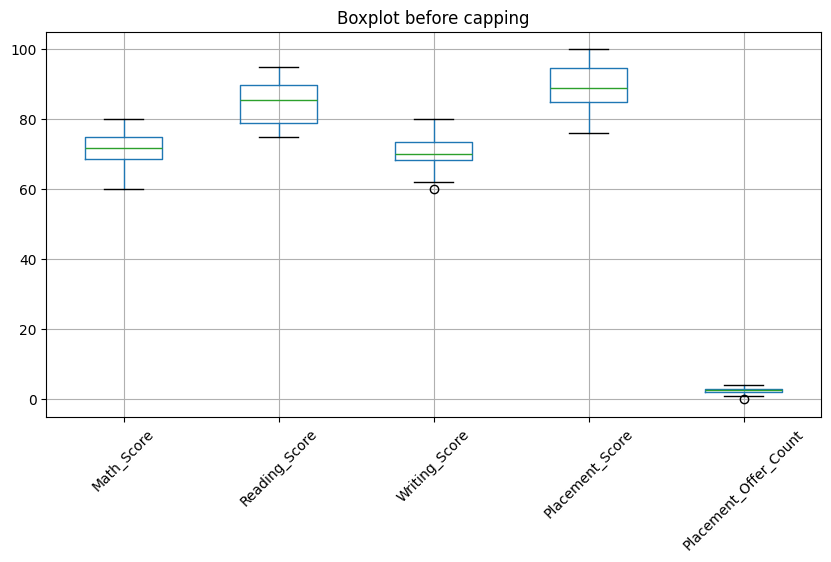

In [28]:
# Boxplot before capping
plt.figure(figsize=(10,5))
df.boxplot(column=numeric_cols)
plt.title('Boxplot before capping')
plt.xticks(rotation=45)
plt.show()

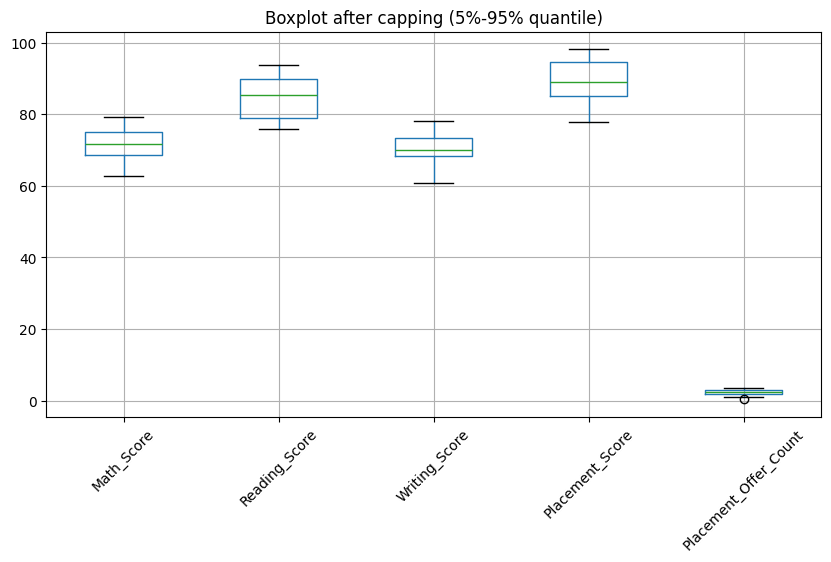

In [ ]:
df_capped = df.copy()
for col in numeric_cols:
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)
    df_capped[col] = np.where(df_capped[col] < lower, lower, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper, upper, df_capped[col])
# Boxplot after capping
plt.figure(figsize=(10,5))
df_capped.boxplot(column=numeric_cols)
plt.title('Boxplot after capping (5%-95% quantile)')
plt.xticks(rotation=45)
plt.show()

## 3) Data transformation

We apply a Min–Max scaling to `Placement_Score` to change its scale to [0,1], which can help algorithms and readers compare features on a common scale. We show the distribution before and after scaling.

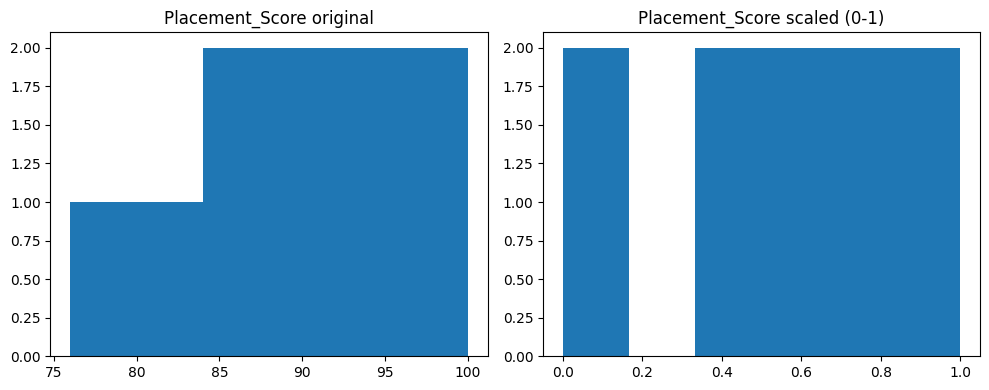

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count,Placement_Score_Scaled
0,75.0,78.0,62.0,80,2018.0,1,0.166667
1,70.0,82.0,68.0,85,2019.0,2,0.375000
2,72.0,85.5,70.0,90,2018.0,2,0.583333
3,68.0,75.0,70.0,85,2018.0,3,0.375000
4,75.0,90.0,74.0,95,2020.0,3,0.791667


In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
placement_orig = df[['Placement_Score']].copy()
df_trans = df.copy()
df_trans['Placement_Score_Scaled'] = scaler.fit_transform(placement_orig)
# Compare distributions
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['Placement_Score'], bins=6)
plt.title('Placement_Score original')
plt.subplot(1,2,2)
plt.hist(df_trans['Placement_Score_Scaled'], bins=6)
plt.title('Placement_Score scaled (0-1)')
plt.tight_layout()
plt.show()
# Show first rows with new column
df_trans.head()

In [ ]:
df_capped['Placement_Score_Scaled'] = df_trans['Placement_Score_Scaled']
df_capped.to_csv('Students_Performance_cleaned.csv', index=False)
'Students_Performance_cleaned.csv saved'

df_capped

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count,Placement_Score_Scaled
0,75.000000,78.00,62.0,80.0,2018.0,1.00,0.166667
1,70.000000,82.00,68.0,85.0,2019.0,2.00,0.375000
2,72.000000,85.50,70.0,90.0,2018.0,2.00,0.583333
3,68.000000,75.90,70.0,85.0,2018.0,3.00,0.375000
4,75.000000,90.00,74.0,95.0,2020.0,3.00,0.791667
5,79.100000,93.65,78.2,98.2,2021.0,3.55,1.000000
6,62.700000,77.00,60.9,77.8,2018.0,0.45,0.000000
7,78.000000,92.00,76.0,96.0,2021.0,3.00,0.833333
8,66.000000,85.50,69.0,88.0,2020.0,2.00,0.500000
9,71.555556,89.00,72.0,93.0,2021.0,3.00,0.708333
